# **Import**

In [2]:
import warnings

warnings.filterwarnings('ignore')

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.metrics import mean_squared_error
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# !pip install optuna
import optuna

# **Data Load**

In [3]:
cd /content/drive/MyDrive/[Projects]/Dacon/운수종사자 인지적 특성 데이터를 활용한 교통사고 위험 예측 AI 경진대회/Data

/content/drive/MyDrive/[Projects]/Dacon/운수종사자 인지적 특성 데이터를 활용한 교통사고 위험 예측 AI 경진대회/Data


In [4]:
train_b = pd.read_csv('train_b_derived.csv')
train_b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297513 entries, 0 to 297512
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Label                    297513 non-null  int64  
 1   Age                      297513 non-null  int64  
 2   B1_task1_accuracy        297513 non-null  float64
 3   B1_task2_change_acc      297513 non-null  float64
 4   B1_task2_non_change_acc  297513 non-null  float64
 5   B1_task2_accuracy_gap    297513 non-null  float64
 6   B1_task2_mean_rt         297513 non-null  float64
 7   B2_task1_accuracy        297513 non-null  float64
 8   B2_task2_change_acc      297513 non-null  float64
 9   B2_task2_non_change_acc  297513 non-null  float64
 10  B2_task2_accuracy_gap    297513 non-null  float64
 11  B2_task2_mean_rt         297513 non-null  float64
 12  B3_accuracy              297513 non-null  float64
 13  B3_mean_rt               297513 non-null  float64
 14  B4_c

# **Hyperparameter Tuning**

In [5]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy='uniform')
    bin_totals = np.histogram(y_prob, bins=np.linspace(0, 1, n_bins + 1), density=False)[0]
    non_empty_bins = bin_totals > 0
    bin_weights = bin_totals / len(y_prob)
    bin_weights = bin_weights[non_empty_bins]
    prob_true = prob_true[:len(bin_weights)]
    prob_pred = prob_pred[:len(bin_weights)]
    ece = np.sum(bin_weights * np.abs(prob_true - prob_pred))
    return ece

def auc_brier_ece(answer_df, submission_df):
    if submission_df.isnull().values.any():
        raise ValueError("The submission dataframe contains missing values.")

    if len(answer_df.columns) != len(submission_df.columns) or not all(answer_df.columns == submission_df.columns):
        raise ValueError("The columns of the answer and submission dataframes do not match.")

    submission_df = submission_df[submission_df.iloc[:, 0].isin(answer_df.iloc[:, 0])]
    submission_df.index = range(submission_df.shape[0])

    auc_scores, brier_scores, ece_scores = [], [], []

    for column in answer_df.columns[1:]:
        y_true = answer_df[column]
        y_prob = submission_df[column]
        auc_scores.append(roc_auc_score(y_true, y_prob))
        brier_scores.append(mean_squared_error(y_true, y_prob))
        ece_scores.append(expected_calibration_error(y_true, y_prob))

    mean_auc = np.mean(auc_scores)
    mean_brier = np.mean(brier_scores)
    mean_ece = np.mean(ece_scores)
    combined_score = 0.5 * (1 - mean_auc) + 0.25 * mean_brier + 0.25 * mean_ece
    return combined_score

In [6]:
x = train_b.drop(columns=['Label'])
y = train_b['Label']

x_train, x_val, y_train, y_val = train_test_split(x,
                                                  y,
                                                  test_size=0.2,
                                                  stratify=y,
                                                  random_state=42)

smote = SMOTE(random_state=42)
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

scaler = StandardScaler()
x_train_res = scaler.fit_transform(x_train_res)
x_val = scaler.transform(x_val)

## **LightGBM**

In [ ]:
def objective_lgb_auc(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
    }

    model = LGBMClassifier(
        **param,
        n_jobs=-1,            # 모든 코어 사용
        force_col_wise=True,  # 병렬 최적화
        verbosity=-1          # 로그 줄이기
    )
    model.fit(x_train_res, y_train_res)

    preds_proba = model.predict_proba(x_val)[:, 1]
    return roc_auc_score(y_val, preds_proba)

study_lgb = optuna.create_study(direction="maximize")
study_lgb.optimize(objective_lgb_auc, n_trials=20)

print("Best LightGBM params:", study_lgb.best_params)
print("Best LightGBM AUC:", study_lgb.best_value)
# Best LightGBM params: {'n_estimators': 621, 'max_depth': 4,
#                        'learning_rate': 0.07942244369633647,
#                        'num_leaves': 121, 'subsample': 0.6439185360254853,
#                        'colsample_bytree': 0.696159562434268}
# Best LightGBM AUC: 0.540911651777989

In [8]:
best_lgb = LGBMClassifier(
    **study_lgb.best_params
)

# 학습
best_lgb.fit(x_train_res, y_train_res)

lgb_preds_proba = best_lgb.predict_proba(x_val)[:, 1]

x_val_df = pd.DataFrame(x_val)
answer_df = pd.DataFrame({'id': x_val_df.index, 'target': y_val})
submission_df = pd.DataFrame({'id': x_val_df.index, 'target': lgb_preds_proba})

auc = roc_auc_score(y_val, lgb_preds_proba)
brier = mean_squared_error(y_val, lgb_preds_proba)
ece = expected_calibration_error(y_val, lgb_preds_proba)
combined_score = auc_brier_ece(answer_df, submission_df)

print(f'AUC: {auc}')
print(f'Brier: {brier}')
print(f'ECE: {ece}')
print(f'Combined Score: {combined_score}')

AUC: 0.540911651777989
Brier: 0.04059584669645852
ECE: 0.0018910162677877528
Combined Score: 0.24016588985206705


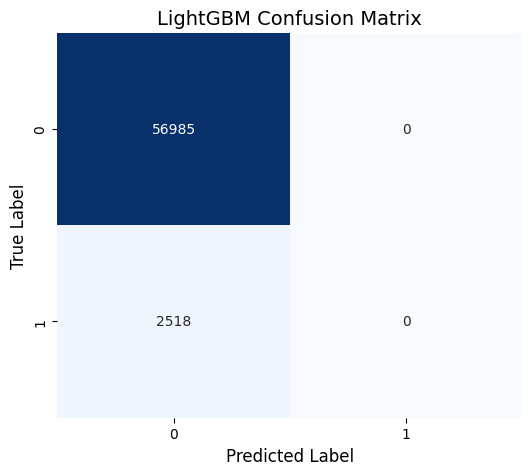

In [9]:
lgb_preds_class = best_lgb.predict(x_val)
cm_lgb = confusion_matrix(y_val, lgb_preds_class)

plt.figure(figsize=(6, 5))

sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("LightGBM Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.show()

## **XGBoost**

In [ ]:
def objective_xgb_auc(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "use_label_encoder": False,
        "eval_metric": "logloss",
        "tree_method": "hist",
        "n_jobs": -1
    }

    model = XGBClassifier(
        **param
    )
    model.fit(x_train_res, y_train_res)

    preds_proba = model.predict_proba(x_val)[:, 1]
    return roc_auc_score(y_val, preds_proba)

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb_auc, n_trials=20)

print("Best XGBoost params:", study_xgb.best_params)
print("Best XGBoost AUC:", study_xgb.best_value)
# Best XGBoost params: {'n_estimators': 439, 'max_depth': 3,
#                       'learning_rate': 0.2634310641976098,
#                       'subsample': 0.9798840160595507,
#                       'colsample_bytree': 0.9924167552706376}
# Best XGBoost AUC: 0.5387871360598705

In [11]:
best_xgb = XGBClassifier(
    **study_xgb.best_params
)

best_xgb.fit(x_train_res, y_train_res)

xgb_preds_proba = best_xgb.predict_proba(x_val)[:, 1]

x_val_df = pd.DataFrame(x_val)
answer_df = pd.DataFrame({'id': x_val_df.index, 'target': y_val})
submission_df = pd.DataFrame({'id': x_val_df.index, 'target': xgb_preds_proba})

auc = roc_auc_score(y_val, xgb_preds_proba)
brier = mean_squared_error(y_val, xgb_preds_proba)
ece = expected_calibration_error(y_val, xgb_preds_proba)
combined_score = auc_brier_ece(answer_df, submission_df)

print(f'AUC: {auc}')
print(f'Brier: {brier}')
print(f'ECE: {ece}')
print(f'Combined Score: {combined_score}')

AUC: 0.5387871360598705
Brier: 0.04064515233039856
ECE: 0.0017115043627285752
Combined Score: 0.24119559614334654


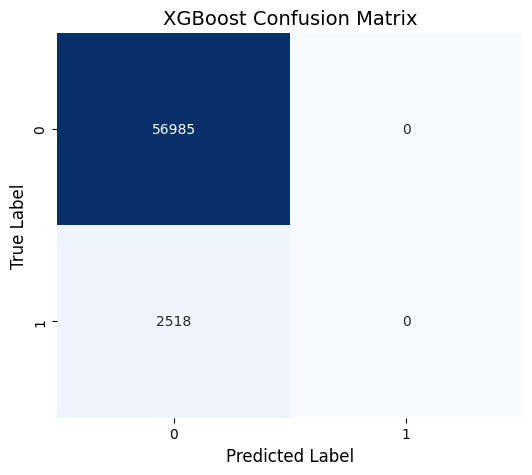

In [12]:
xgb_preds_class = best_xgb.predict(x_val)
cm_xgb = confusion_matrix(y_val, xgb_preds_class)

plt.figure(figsize=(6, 5))

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("XGBoost Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.show()

## **DNN**

In [ ]:
def objective_dnn(trial):
    n_layers = trial.suggest_int("n_layers", 1, 12)
    units = trial.suggest_categorical("units", [32, 64, 128, 256])
    dropout_rate = trial.suggest_float("dropout", 0.0, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])

    model = Sequential()
    model.add(Dense(units, input_dim=x_train_res.shape[1], activation='relu'))
    model.add(BatchNormalization())
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    for _ in range(n_layers - 1):
        model.add(Dense(units, activation='relu'))
        model.add(BatchNormalization())
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])

    # EarlyStopping
    es_callbacks = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # 학습
    model.fit(
        x_train_res, y_train_res,
        validation_data=(x_val, y_val),
        epochs=50,        # 빠른 튜닝을 위해 epoch 줄임
        batch_size=batch_size,
        callbacks=[es_callbacks],
        verbose=0
    )

    # 검증 데이터 AUC 계산
    preds = model.predict(x_val).ravel()
    return roc_auc_score(y_val, preds)

# Optuna study
study_dnn = optuna.create_study(direction="maximize")
study_dnn.optimize(objective_dnn, n_trials=20)  # trial 수 조정 가능

print("Best DNN params:", study_dnn.best_params)
print("Best DNN AUC:", study_dnn.best_value)
# Best DNN params: {'n_layers': 5, 'units': 256, 'dropout': 0.04344158435932281,
#                   'lr': 0.009417256922354584, 'batch_size': 128}
# Best DNN AUC: 0.5151738682678014

In [ ]:
dnn_model = Sequential()
n_layers = study_dnn.best_params['n_layers']
units = study_dnn.best_params['units']
dropout_rate = study_dnn.best_params['dropout']
lr = study_dnn.best_params['lr']

dnn_model.add(Dense(units, input_dim=x_train_res.shape[1], activation='relu'))
dnn_model.add(BatchNormalization())
if dropout_rate > 0:
    dnn_model.add(Dropout(dropout_rate))

for _ in range(n_layers - 1):
    dnn_model.add(Dense(units, activation='relu'))
    dnn_model.add(BatchNormalization())
    if dropout_rate > 0:
        dnn_model.add(Dropout(dropout_rate))
dnn_model.add(Dense(1, activation='sigmoid'))

dnn_model.compile(optimizer=Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = dnn_model.fit(
    x_train_res, y_train_res,
    validation_data=(x_val, y_val),
    epochs=500,
    batch_size=study_dnn.best_params['batch_size'],
    callbacks=[early_stop],
    verbose=1
)

dnn_preds_proba = dnn_model.predict(x_val).ravel()

x_val_df = pd.DataFrame(x_val)
answer_df = pd.DataFrame({'id': x_val_df.index, 'target': y_val})
submission_df = pd.DataFrame({'id': x_val_df.index, 'target': dnn_preds_proba})

auc = roc_auc_score(y_val, dnn_preds_proba)
brier = mean_squared_error(y_val, dnn_preds_proba)
ece = expected_calibration_error(y_val, dnn_preds_proba)
combined_score = auc_brier_ece(answer_df, submission_df)

In [9]:
print(f'AUC: {auc}')
print(f'Brier: {brier}')
print(f'ECE: {ece}')
print(f'Combined Score: {combined_score}')

AUC: 0.4962941176429593
Brier: 0.05205954238772392
ECE: 0.05648484752407323
Combined Score: 0.2789890386564696


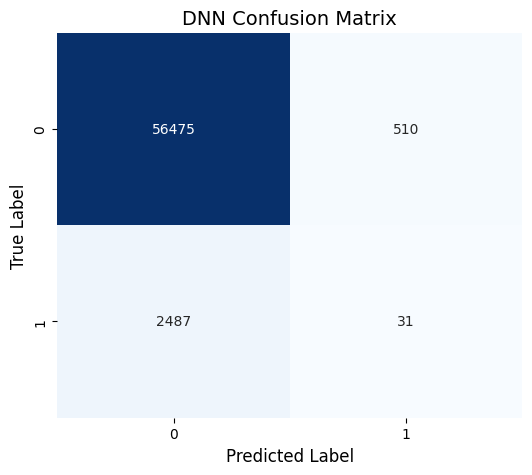

In [10]:
dnn_preds_class = (dnn_preds_proba >= 0.5).astype(int)
cm_dnn = confusion_matrix(y_val, dnn_preds_class)

plt.figure(figsize=(6,5))

sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('DNN Confusion Matrix', fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)


plt.show()

# **Result**

In [9]:
results_df = pd.DataFrame(results)
results_df.sort_values('Combined')

,Model,AUC,Brier,ECE,Combined
0,LightGBM,0.540912,0.040596,0.001891,0.240166
1,XGBoost,0.538787,0.040645,0.001712,0.241196
2,DNN,0.496294,0.052060,0.056485,0.278989
